# Customer Sentiment & Aspect-Based Opinion Mining on Amazon Fine Food Reviews using NLP and Machine Learning

# Amazon Reviews Sentiment Analysis

# Project Objective

To analyze customer sentiment, detect emotions, and extract aspect-level opinions from large-scale e-commerce reviews using Natural Language Processing (NLP), Machine Learning, and Deep Learning, and generate business-driven insights.

# Install & Import Required Libraries

In [22]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sahil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sahil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Load the Dataset

In [24]:
df = pd.read_csv("Reviews.csv")
print("Dataset Shape:", df.shape)
df.head()



Dataset Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# Data Understanding & Basic Cleaning

In [25]:
# Check missing values
df.isnull().sum()


Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [26]:
# Keep only required columns
df = df[['Score', 'Summary', 'Text']]

# Drop missing values
df.dropna(inplace=True)

df.head()


,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


# Exploratory Data Analysis (EDA)

# Rating Distribution

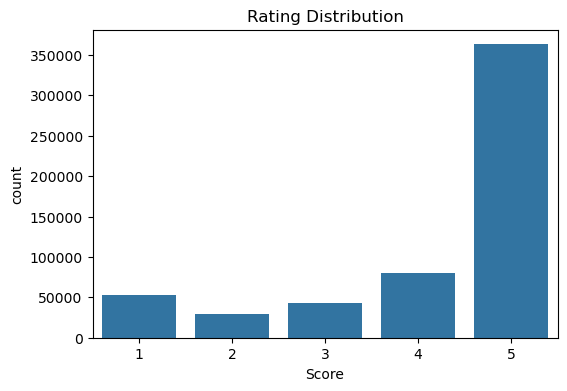

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='Score', data=df)
plt.title("Rating Distribution")
plt.show()

# Review Length Analysis

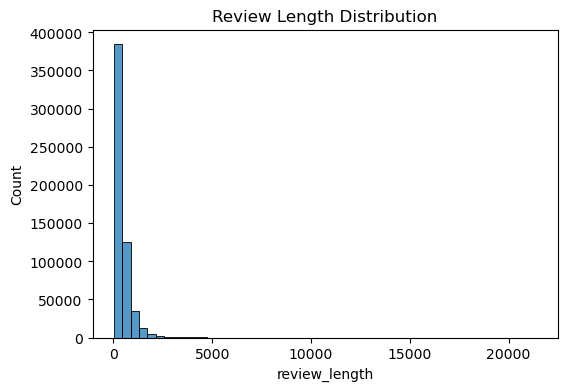

In [28]:
df['review_length'] = df['Text'].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()


# Sentiment Label Creation

In [29]:
def sentiment_label(score):
    if score > 3:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Score'].apply(sentiment_label)
df['Sentiment'].value_counts()


Sentiment
Positive    443777
Negative     82012
Neutral      42638
Name: count, dtype: int64

# Text Preprocessing Function

In [30]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    return " ".join(text)


In [31]:
df['clean_text'] = df['Text'].apply(clean_text)
df[['Text', 'clean_text']].head()


,Text,clean_text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanut pe...
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


# Train-Test Split

In [32]:
X = df['clean_text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Feature Engineering (TF-IDF)

In [33]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


# Baseline Model – Logistic Regression

In [34]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)


# Model Evaluation

In [35]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

    Negative       0.74      0.68      0.71     16402
     Neutral       0.53      0.21      0.30      8528
    Positive       0.90      0.97      0.93     88756

    accuracy                           0.87    113686
   macro avg       0.72      0.62      0.65    113686
weighted avg       0.85      0.87      0.85    113686



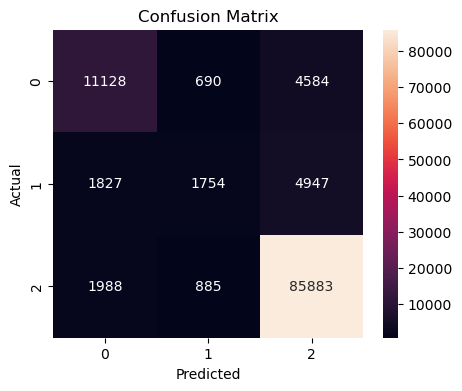

In [36]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show() 


# Sample Prediction

In [37]:
sample_review = ["The taste is amazing but packaging was very poor"]
sample_clean = [clean_text(sample_review[0])]
sample_vector = tfidf.transform(sample_clean)

model.predict(sample_vector)


array(['Positive'], dtype=object)

In [38]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [39]:
# Shapes check
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)


(454741, 5000)
(113686, 5000)


# Model 1: Support Vector Machine (SVM)

In [40]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)


In [41]:
print("SVM Classification Report:\n")
print(classification_report(y_test, svm_pred))


SVM Classification Report:

              precision    recall  f1-score   support

    Negative       0.74      0.69      0.71     16402
     Neutral       0.60      0.13      0.22      8528
    Positive       0.89      0.97      0.93     88756

    accuracy                           0.87    113686
   macro avg       0.74      0.60      0.62    113686
weighted avg       0.85      0.87      0.85    113686



In [42]:
svm_acc = accuracy_score(y_test, svm_pred)
svm_acc


0.868154390162377

# Model 2: Random Forest Classifier

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)


In [44]:
print("Random Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))


Random Forest Classification Report:

              precision    recall  f1-score   support

    Negative       0.98      0.16      0.27     16402
     Neutral       1.00      0.03      0.06      8528
    Positive       0.80      1.00      0.89     88756

    accuracy                           0.81    113686
   macro avg       0.93      0.40      0.41    113686
weighted avg       0.84      0.81      0.74    113686



In [45]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_acc


0.8055345425118309

# Confusion Matrix Comparison

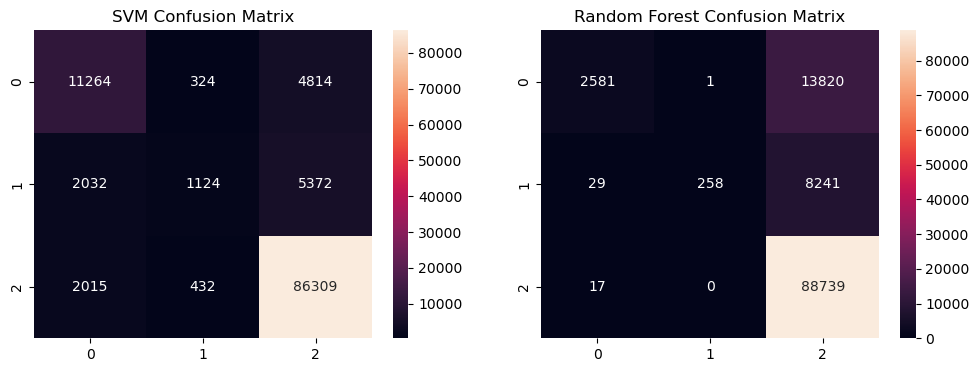

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.heatmap(confusion_matrix(y_test, svm_pred), 
            annot=True, fmt='d', ax=axes[0])
axes[0].set_title("SVM Confusion Matrix")

sns.heatmap(confusion_matrix(y_test, rf_pred), 
            annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Random Forest Confusion Matrix")

plt.show()


# Accuracy Comparison Table

In [47]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),  # from previous notebook
        svm_acc,
        rf_acc
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.868753
1,SVM,0.868154
2,Random Forest,0.805535


# Visualization – Model Performance

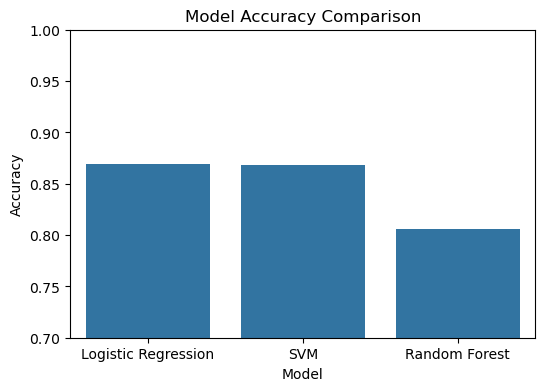

In [48]:
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.ylim(0.7, 1.0)
plt.show()


In [ ]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-20:]

features = tfidf.get_feature_names_out()

top_features = pd.DataFrame({
    "Feature": features[indices],
    "Importance": importances[indices]
}).sort_values(by="Importance", ascending=False)

top_features


# Aspect-Based Sentiment Analysis (ABSA)

In [ ]:
import nltk
from nltk import pos_tag, word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')


# Define Aspect Keywords (Domain Knowledge)

In [ ]:
ASPECT_KEYWORDS = {
    "taste": ["taste", "flavor", "sweet", "bitter", "salty"],
    "quality": ["quality", "fresh", "stale"],
    "price": ["price", "cost", "value", "expensive", "cheap"],
    "packaging": ["package", "packaging", "box", "seal"],
    "delivery": ["delivery", "shipping", "arrived"],
    "quantity": ["quantity", "amount", "size"]
}


# Aspect Extraction Function

In [ ]:
def extract_aspects(text):
    tokens = word_tokenize(text.lower())
    tagged = pos_tag(tokens)

    aspects_found = set()

    for word, tag in tagged:
        if tag.startswith('NN'):  # noun
            for aspect, keywords in ASPECT_KEYWORDS.items():
                if word in keywords:
                    aspects_found.add(aspect)

    return list(aspects_found)


# Aspect Sentiment Detection (VADER)

In [ ]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"


# Combine Aspect + Sentiment

In [ ]:
def aspect_sentiment_analysis(text):
    aspects = extract_aspects(text)
    sentiment = get_sentiment(text)

    results = []
    for aspect in aspects:
        results.append({
            "Aspect": aspect,
            "Sentiment": sentiment
        })
    return results


# Test on Real Reviews (IMPORTANT)

In [ ]:
sample_review = "The taste is amazing but the packaging was very poor"

aspect_sentiment_analysis(sample_review)


In [ ]:
 # Apply ABSA to Dataset (Sample)

In [ ]:
df_absa = df.sample(1000, random_state=42)

df_absa['aspect_sentiment'] = df_absa['Text'].apply(aspect_sentiment_analysis)
df_absa[['Text', 'aspect_sentiment']].head()


# Business Insights from ABSA

In [ ]:
rows = []

for _, row in df_absa.iterrows():
    for item in row['aspect_sentiment']:
        rows.append({
            "Aspect": item['Aspect'],
            "Sentiment": item['Sentiment']
        })

aspect_df = pd.DataFrame(rows)
aspect_df.head()


# Aspect Sentiment Distribution

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Aspect', hue='Sentiment', data=aspect_df)
plt.title("Aspect-Based Sentiment Distribution")
plt.xticks(rotation=45)
plt.show()


In [ ]:
!pip install transformers torch datasets


In [ ]:
import torch
import pandas as pd
import numpy as np

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [ ]:
df = df[['clean_text', 'Sentiment']].dropna()

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

df[['Sentiment', 'label']].head()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)


In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_data(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize_data(X_train)
test_encodings = tokenize_data(X_test)


In [ ]:
class AmazonDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [ ]:
train_dataset = AmazonDataset(train_encodings, y_train)
test_dataset = AmazonDataset(test_encodings, y_test)


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)



In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    logging_dir="./logs",
    save_strategy="epoch",
    load_best_model_at_end=True
)



In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()



In [ ]:
# Evaluate Model
trainer.evaluate()

In [ ]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=1)
    return label_encoder.inverse_transform(prediction.numpy())[0]
